<h1 style="color:white;text-align:center;font-family:'Georgia';background-color:#003366;padding:20px;border-radius:12px;">
  🎯 PROJET DATA MINING : Segmentation de la Clientèle
</h1>

<p style="color:white;text-align:center;font-family:'Georgia';background-color:#003366;padding:20px;border-radius:12px;">
  REALISE PAR
</p>

* **KONE Abdoulaye** 
* **N’GUESSAN Kouamé Kan Armand Loïc**
* **SAWADOGO Wend-yam Albert**
* **CHEFOUET CHETSONG GHISLAIN JOEL**
<p style="color:white;text-align:center;font-family:'Georgia';background-color:#003366;padding:20px;border-radius:12px;">
  SUPERVISE
</p>

* **M. LALY** 




<img src="images/segmentation1.jpg">

Pour aborder notre projet, nous allons appliquer une technique de **clustering non supervisé** sur des données issues d’une entreprise du secteur de la grande distribution.


🔍 Objectifs :
- Identifier des groupes de clients distincts.
- Adapter les produits/services aux besoins spécifiques de chaque segment.
- Améliorer la prise de décision basée sur les données.

---


   <a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">

<p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;padding:20px;text-align:center;border-radius:10px 10px;"> TABLE DES MATIERES</p>   
    
* [1. IMPORTING LIBRARIES](#1)
    
* [2. LOADING DATA](#2)
    
* [3. DATA CLEANING](#3)
    
* [4. DATA PREPROCESSING](#4)   
    
* [5. DIMENSIONALITY REDUCTION](#5) 
      
* [6. CLUSTERING](#6)
    
* [7. EVALUATING MODELS](#7)
    
* [8. PROFILING](#8)
    
* [9. CONCLUSION](#9)



<a id="1"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;"> 📦 IMPORTING LIBRARIES</p>



In [2]:
## 📦 Importation des bibliothèques

import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

# Prétraitement
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
#from yellowbrick.cluster import KElbowVisualizer
from sklearn import metrics

# Visualisation 3D
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import missingno as msno
import matplotlib.pyplot as plt
# Suppression des warnings
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Fixer la graine pour la reproductibilité
np.random.seed(42)


***

<a id="2"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;"> 🧹 LOADING DATA</p>



In [ ]:
#Chargement des données
data = pd.read_csv("data/marketing_campaign.csv", sep="\t")
print("Nombre de lignes:", len(data))
data.head()

Nombre de lignes: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# Taille des données
data.shape

(2240, 29)

***


<a id="3"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">🧹 DATA CLEANING</p>

**🔍 Dans cette section**
Nous allons faire:
* Le nettoyage des données  
* La création et transformation de variables (feature engineering)

---
Afin de déterminer précisément les étapes nécessaires au nettoyage du jeu de données, nous allons commencer par explorer les informations disponibles sur la structure des données.


In [5]:
#Information sur les variables 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

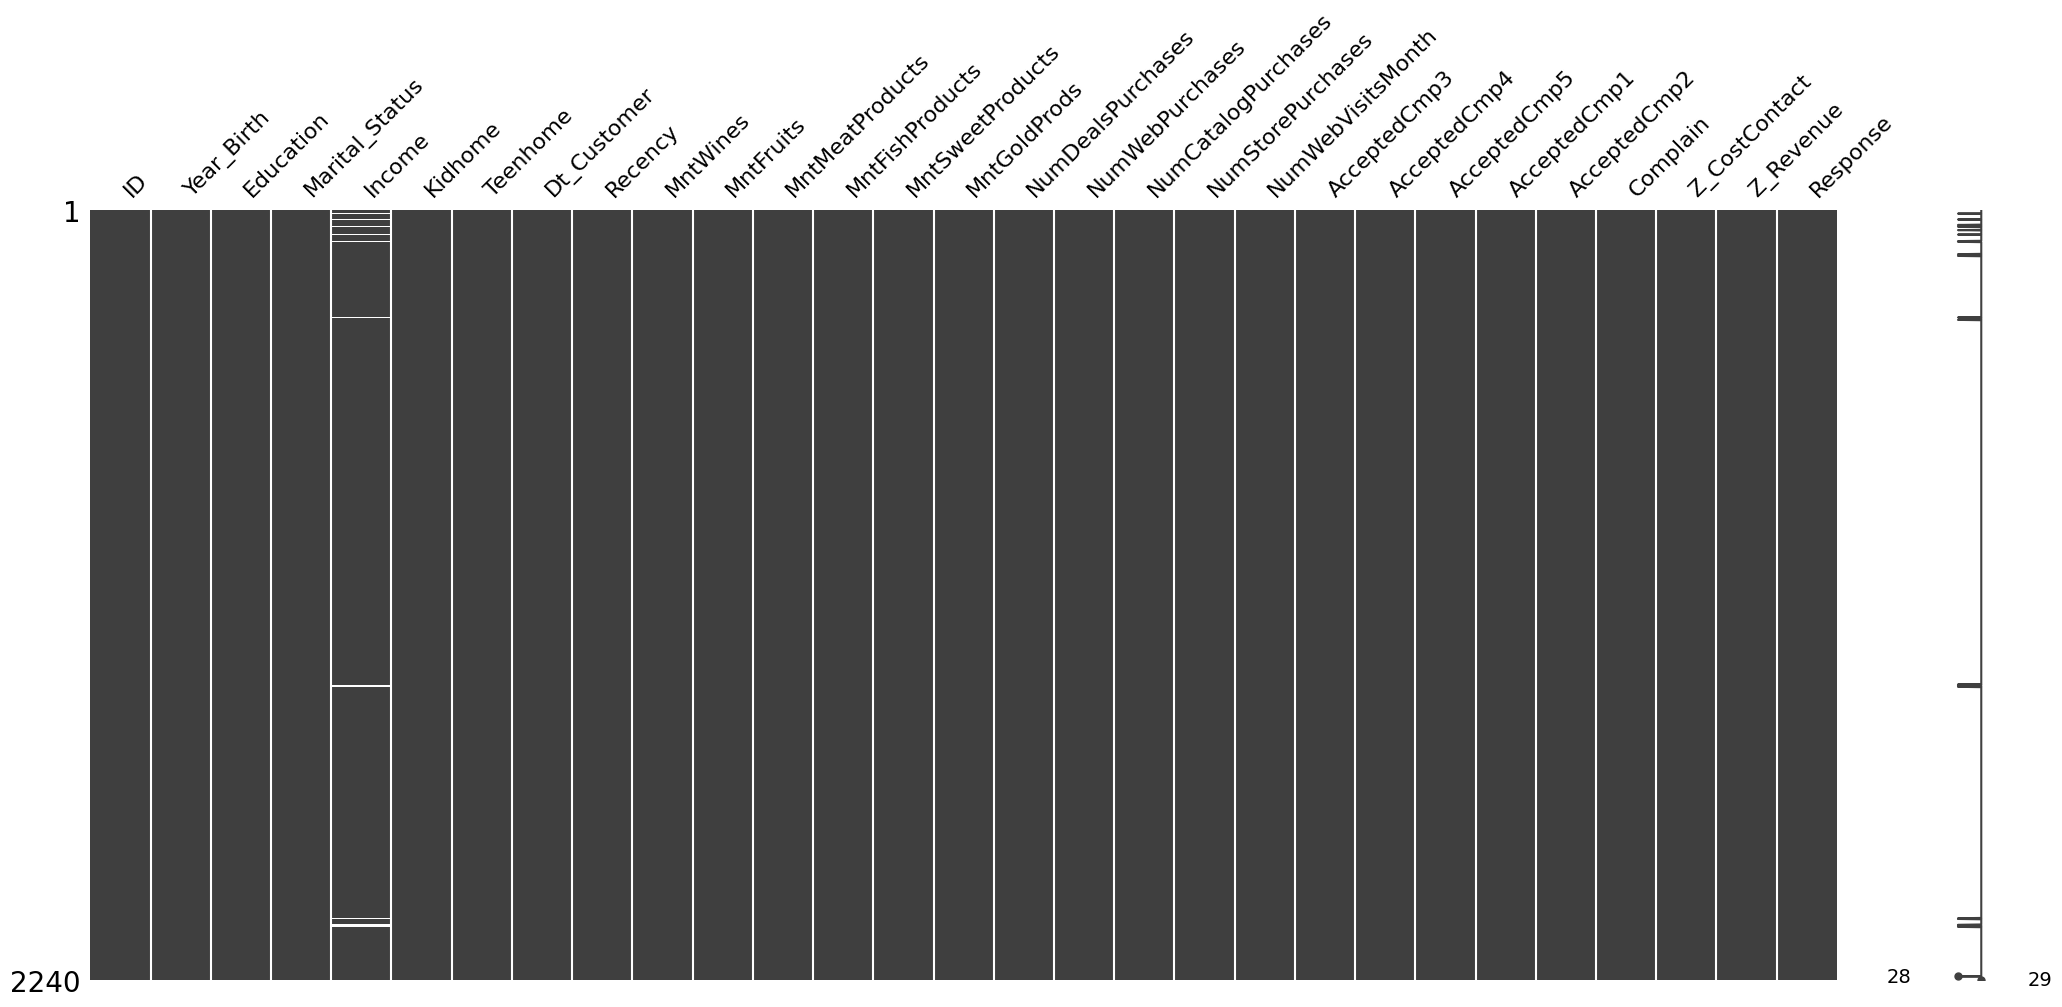

In [6]:
# Affichage des valeurs manquantes sous forme de graphique
msno.matrix(data)
plt.show()


**📌 À partir des informations sur les variables, nous pouvons tirer les conclusions suivantes**

* La variable `Income` contient des valeurs manquantes.
* La variable `Dt_Customer`, qui représente la date d’enregistrement du client dans la base de données, n’a pas encore été convertie au format `DateTime`.
* Certaines variables du jeu de données sont de type catégoriel (`object`). Il faudra donc les encoder en variables numériques par la suite.

🔧 Dans un premier temps, nous allons supprimer les lignes contenant des valeurs manquantes dans la variable `Income`.


In [7]:
#To remove the NA values
data = data.dropna()
print("Le nombre total de ligne après la suppression des valeurs manquantes est:", len(data))

Le nombre total de ligne après la suppression des valeurs manquantes est: 2216


**🛠️ Création d'une nouvelle variable à partir de `Dt_Customer`**

Nous allons maintenant créer une variable dérivée de **`Dt_Customer`** afin d’estimer le **nombre de jours depuis l'enregistrement de chaque client** dans la base de données de l’entreprise.

👉 Pour simplifier l’analyse, cette durée sera calculée **par rapport à la date d’enregistrement la plus récente** observée dans les données.

Avant de procéder, examinons les dates les plus anciennes et les plus récentes présentes dans la colonne `Dt_Customer`.


In [8]:
# Conversion en datetime en tenant compte du format jour-mois-année
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)

# Extraction des dates sans l'heure
dates = [i.date() for i in data["Dt_Customer"]]

# Affichage de la date la plus récente et la plus ancienne
print("📅 Date d'enregistrement la plus récente :", max(dates))
print("📅 Date d'enregistrement la plus ancienne :", min(dates))


📅 Date d’enregistrement la plus récente : 2014-06-29
📅 Date d’enregistrement la plus ancienne : 2012-07-30


In [9]:
#Création de la variable "Customer_For"
days = []
d1 = max(dates) 
for i in dates:
    delta = d1 - i
    days.append(delta)
data["Customer_For"] = days
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

**🔍 Exploration des variables catégorielles**

Nous allons maintenant examiner les **valeurs uniques** des variables catégorielles afin d’obtenir une vision plus claire de leur contenu et de mieux comprendre la structure des données.


In [10]:
print("📊 Répartition des catégories dans la variable 'Marital_Status' :\n")
print(data["Marital_Status"].value_counts(), "\n")

print("🎓 Répartition des catégories dans la variable 'Education' :\n")
print(data["Education"].value_counts())


📊 Répartition des catégories dans la variable 'Marital_Status' :

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

🎓 Répartition des catégories dans la variable 'Education' :

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


Pour mieur faire le profilage, nous allons maintenant:

- Extraire l’**âge** d’un client à partir de la variable **`Year_Birth`**, qui indique son année de naissance.
- Créer une nouvelle variable **`Spent`** représentant le **montant total dépensé** par le client dans différentes catégories sur une période de deux ans.
- Créer une variable **`Living_With`** à partir de **`Marital_Status`** afin de mieux refléter la **situation de cohabitation** (ex. vit en couple ou non).
- Créer une variable **`Children`** pour indiquer le **nombre total d’enfants dans le foyer**, incluant les enfants et adolescents.
- Pour mieux comprendre la structure du foyer, créer une variable **`Family_Size`** représentant la **taille de la famille**.
- Créer une variable **`Is_Parent`** pour identifier si le client est **parent ou non**.
- Simplifier les modalités de la variable **`Education`** en regroupant ses valeurs en **trois grandes catégories**.
- Supprimer certaines variables devenues **redondantes ou inutiles** après transformation.


In [11]:
# 🛠️ Ingénierie des variables

# 🎂 Âge du client à partir de son année de naissance (en supposant une analyse en 2021)
data["Age"] = 2025 - data["Year_Birth"]

# 💰 Dépense totale du client dans toutes les catégories de produits
data["Spent"] = (
    data["MntWines"] +
    data["MntFruits"] +
    data["MntMeatProducts"] +
    data["MntFishProducts"] +
    data["MntSweetProducts"] +
    data["MntGoldProds"]
)

# 🏠 Situation de cohabitation dérivée du statut matrimonial
data["Living_With"] = data["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Absurd": "Alone",
    "Widow": "Alone",
    "YOLO": "Alone",
    "Divorced": "Alone",
    "Single": "Alone"
})

# 👶 Nombre total d’enfants dans le foyer (enfants + adolescents)
data["Children"] = data["Kidhome"] + data["Teenhome"]

# 👨‍👩‍👧‍👦 Taille de la famille (nombre total de personnes dans le foyer)
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner": 2}) + data["Children"]

# ✅ Indication du statut parental (1 = parent, 0 = non parent)
data["Is_Parent"] = np.where(data["Children"] > 0, 1, 0)

# 🎓 Regroupement des niveaux d’éducation en 3 catégories
data["Education"] = data["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

# 🧼 Renommer les colonnes de dépenses pour plus de clarté
data = data.rename(columns={
    "MntWines": "Wines",
    "MntFruits": "Fruits",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweets",
    "MntGoldProds": "Gold"
})

# 🗑️ Suppression des variables devenues redondantes ou inutiles
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)


Regardons les statistiques avec les nouvelles variables

In [12]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.064079,0.013538,0.009477,0.150271,3.054423e+16,56.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.244950,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,29.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,1.555200e+16,48.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,3.071520e+16,55.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,4.570560e+16,66.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,6.039360e+16,132.000000,2525.000000,3.000000,5.000000,1.000000


Nous observons à travers les statistiques, des écarts entre la moyenne et le maximum des variables **Revenu** et **Âge**.

À noter que l’**âge maximum** est de **132 ans**, car nous avons calculé l’âge en prenant 2025 comme l'année de base.

Nous allons donc prendre du recul pour mieux comprendre l’ensemble du jeu de données. 
Pour ce faire nous allons tracer des graphiques pour certaines variables sélectionnées afin d’avoir une meilleure visibilité.


📊 Représentation graphique de quelques variables sélectionnées :


<Figure size 1200x800 with 0 Axes>

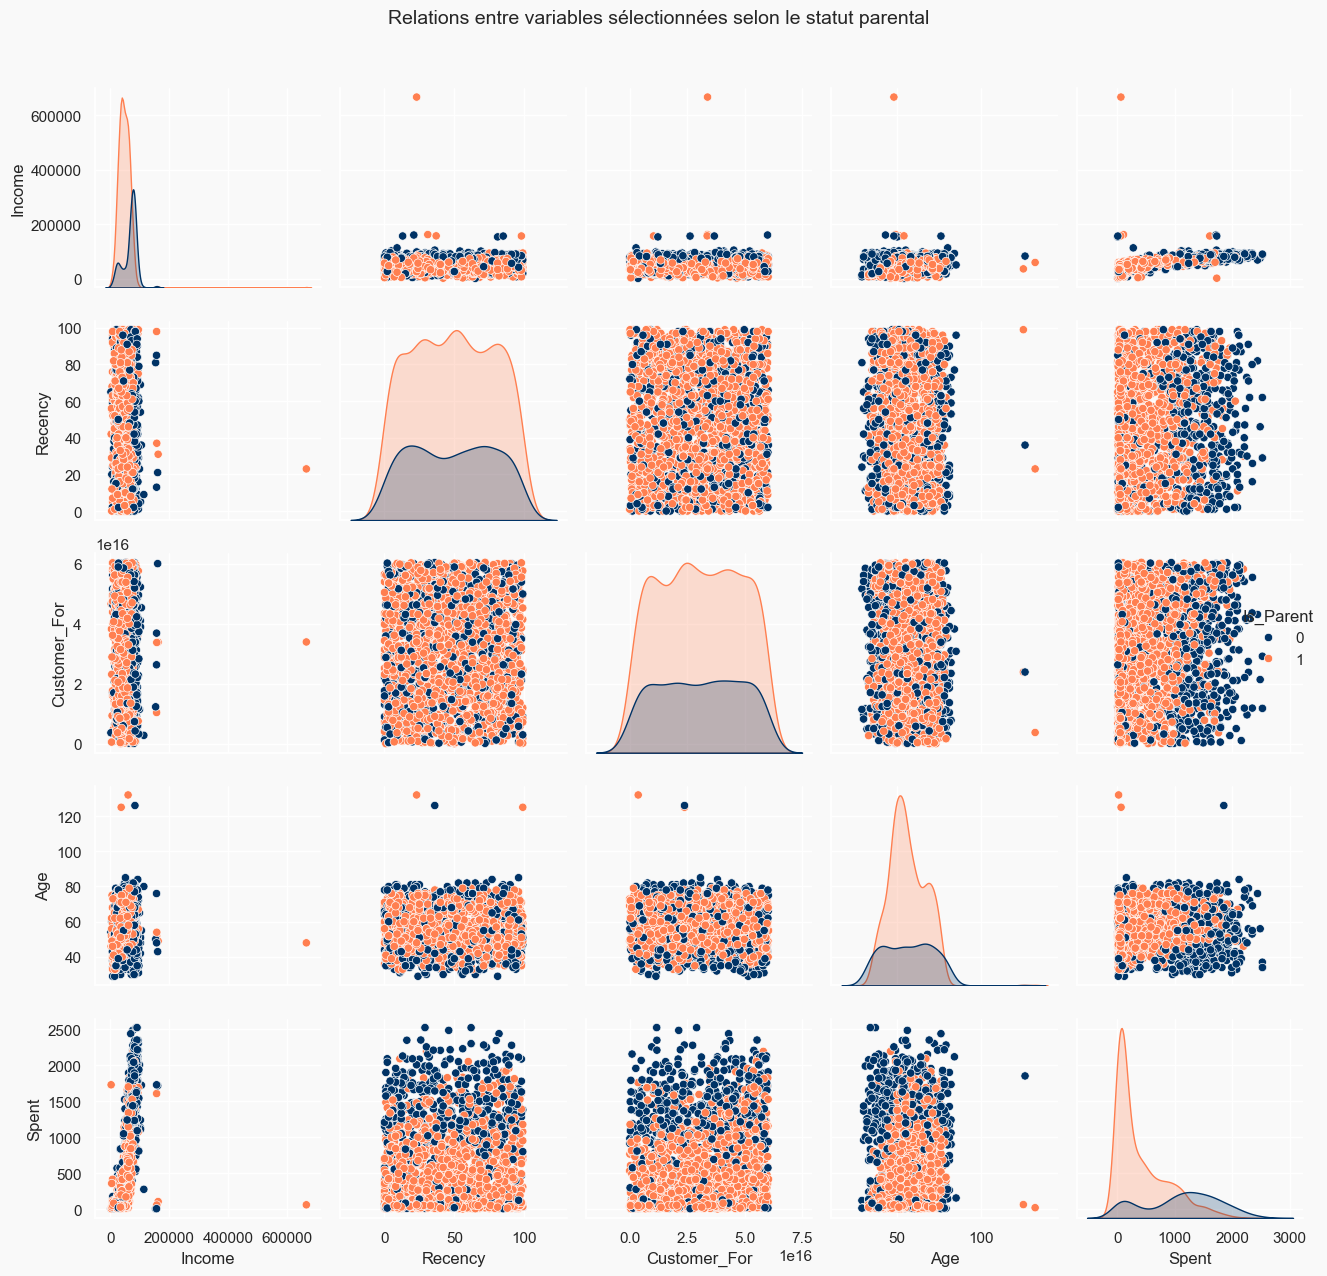

In [13]:
# 🖌️ Définir les couleurs de fond
sns.set(rc={
    "axes.facecolor": "#F9F9F9",
    "figure.facecolor": "#F9F9F9"
})

# 🎨 Nouvelle palette plus moderne et contrastée
palette_custom = ["#4B3F72", "#FF7F50", "#FFD700", "#6CA6CD", "#98FB98", "#D87093"]
cmap = colors.ListedColormap(palette_custom)

# 📊 Variables à tracer
To_Plot = ["Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]

# 🧾 Message explicatif
print("📊 Représentation graphique de quelques variables sélectionnées :")

# 📉 Affichage des relations avec PairPlot
plt.figure(figsize=(12, 8))  # Agrandir légèrement la figure
sns.pairplot(data[To_Plot], hue="Is_Parent", palette=["#003366", "#FF7F50"])
plt.suptitle("Relations entre variables sélectionnées selon le statut parental", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


A travers les graphiques, il est clair qu’il existe quelques valeurs aberrantes dans les variables **Revenu** et **Âge**.  
Pour ne pas qu'il affecte le reste des données, nous allons procéder à la **suppression de ces outliers** dans les données.

In [14]:
# 🔍 Suppression des valeurs aberrantes en fixant un seuil maximal pour l’âge et le revenu

# On retire les individus ayant plus de 90 ans
data = data[(data["Age"] < 90)]

# On retire les individus ayant un revenu supérieur à 600 000
data = data[(data["Income"] < 600000)]

# ✅ Affichage du nombre total d'observations après nettoyage
print("Nombre total d'observations après suppression des valeurs aberrantes :", len(data))


Nombre total d'observations après suppression des valeurs aberrantes : 2212


Ensuite, nous allons examiner la **corrélation entre les différentes variables numériques**.  
Nous allons exclu les variables catégorielles pour l’instant.


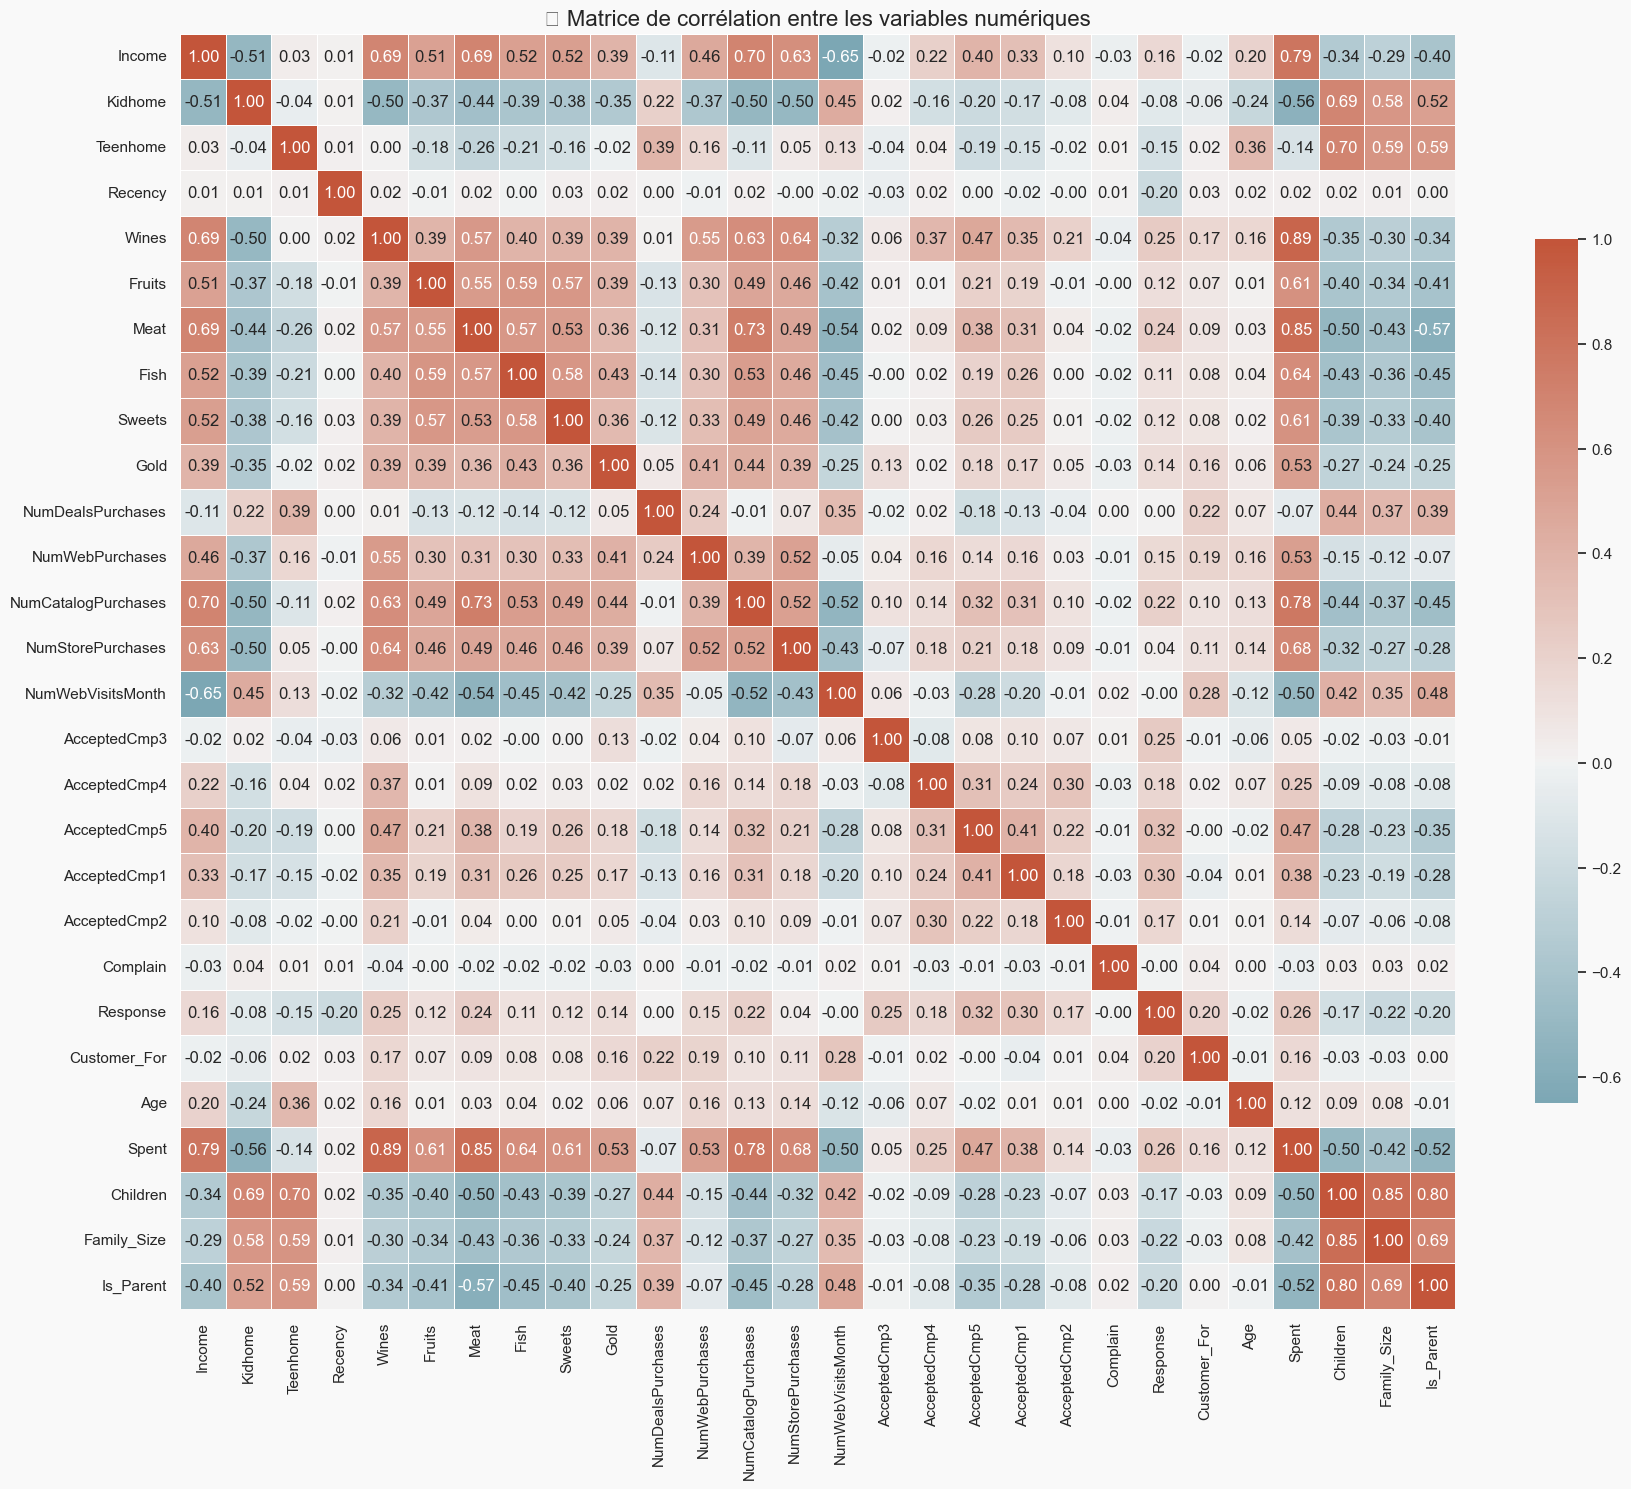

In [15]:
# 🔗 Matrice de corrélation entre les variables numériques

import seaborn as sns
import matplotlib.pyplot as plt

# 🎨 Nouvelle palette de couleurs : dégradé du bleu au rouge
nouvelle_palette = sns.diverging_palette(220, 20, as_cmap=True)

# 📊 Calcul de la matrice de corrélation
corrmat = data.corr(numeric_only=True)

# 🖼️ Affichage de la heatmap
plt.figure(figsize=(18, 18))  # Taille plus compacte et lisible
sns.heatmap(
    corrmat,
    annot=True,            # Affiche les coefficients dans chaque case
    fmt=".2f",             # Format des nombres
    cmap=nouvelle_palette, # Nouvelle palette de couleurs
    center=0,              # Centrer autour de 0 pour bien visualiser les corrélations positives/négatives
    square=True,           # Carrer les cellules
    linewidths=.5,         # Lignes entre les cases
    cbar_kws={"shrink": .5}  # Barre de couleur plus fine
)
plt.title("🔍 Matrice de corrélation entre les variables numériques", fontsize=16)
plt.tight_layout()
plt.show()


**🧩 Interpretation de la matrice de corrélation**

L’analyse de la matrice de corrélation nous permet de mettre en évidence certaines relations intéressantes :

* On observe une **corrélation positive forte** entre les variables liées aux **dépenses** (`Wines`, `Meat`, `Gold`, etc.) et la variable **`Spent`**, ce qui est attendu.
* La variable **`Income`** est modérément corrélée à plusieurs types de dépenses et à la **fréquence d’achat en ligne**.
* L’âge (`Age`) est **négativement corrélé** avec les dépenses et certaines interactions numériques, suggérant que les clients plus jeunes sont plus actifs.
* Le **nombre d’enfants (`Children`)** est corrélé négativement avec les dépenses, ce qui peut indiquer une contrainte budgétaire ou une préférence différente.
* La variable **`Is_Parent`** est aussi inversement liée à certaines habitudes de consommation.

Ces premières observations nous donnent des pistes utiles pour le traitement à venir.
Dans la section suivante, nous allons faire la préparation des données en vue de réaliser des **opérations de clustering**.

---

<a id="4"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;"> ⚙️ PRÉTRAITEMENT DES DONNÉES</p>


**Les étapes suivantes seront appliquées lors du prétraitement :**

* Encodage des variables catégorielles avec **Label Encoding**  
* **Mise à l’échelle** des variables numériques à l’aide du **Standard Scaler**  
* Création d’un **sous-ensemble de données** pour la **réduction de dimensionnalité**


In [16]:
#Optenir la liste des variables catégorielles
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Les variables catégorielles dans la base de données est", object_cols)

Les variables catégorielles dans la base de données est ['Education', 'Living_With']


In [17]:
# 🔤 Encodage des variables catégorielles (type object) avec LabelEncoder

from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

# On applique l'encodage à chaque colonne de type 'object'
for i in object_cols:
    data[i] = data[[i]].apply(LE.fit_transform)

# ✅ Confirmation
print("✅ Toutes les variables sont désormais numériques.")


✅ Toutes les variables sont désormais numériques.


Avant d'appliquer les algorithmes de clustering, il est essentiel de **préparer correctement les données**.  
Nous allons :

* Créer une **copie** du jeu de données pour préserver l’original,
* Supprimer certaines variables **liées aux campagnes marketing** ou peu pertinentes pour le clustering,
* Appliquer une **mise à l’échelle** standardisée sur l’ensemble des variables restantes à l’aide du `StandardScaler`, afin d’assurer une échelle homogène entre les différentes dimensions.


In [18]:
# 📝 Création d’une copie du jeu de données original
ds = data.copy()

# 🗂️ Suppression des variables liées aux campagnes marketing, plaintes et réponses
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1)

# 📏 Mise à l’échelle des données avec StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(ds)

# 🧮 Création d’un nouveau DataFrame avec les données normalisées
scaled_ds = pd.DataFrame(scaler.transform(ds), columns=ds.columns)

# ✅ Confirmation
print("✅ Toutes les variables ont été mises à l'échelle.")


✅ Toutes les variables ont été mises à l'échelle.


In [19]:
# Données mises à l’échelle à utiliser pour la réduction de dimensionnalité
print("DataFrame à utiliser pour la modélisation ultérieure :")
scaled_ds.head()


DataFrame à utiliser pour la modélisation ultérieure :


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


Après le traitément des données, Passons maintenant à la **réduction de dimensionnalité**, une étape clé pour simplifier les données tout en conservant leur information essentielle, facilitant ainsi la visualisation et le clustering.

---


<a id="5"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;"> ⚙️ DIMENSIONALITY REDUCTION</p>
A travers la matrice de corrélation nous avons obsersé que beaucoup de variables sont corrélées entre elle donc une redondance d'informations.

C’est pourquoi nous allons appliquer une **réduction de dimensionnalité** sur les variables sélectionnées avant de les utiliser dans un classificateur.  

Nous allons utiliser **L’Analyse en Composantes Principales (ACP)** permettant de réduire la dimensionnalité de ces jeux de données tout en maximisant l’interprétabilité et en minimisant la perte d’information.

**Étapes dans cette section :**
* Réduction de dimensionnalité avec la PCA  
* Visualisation du jeu de données réduit

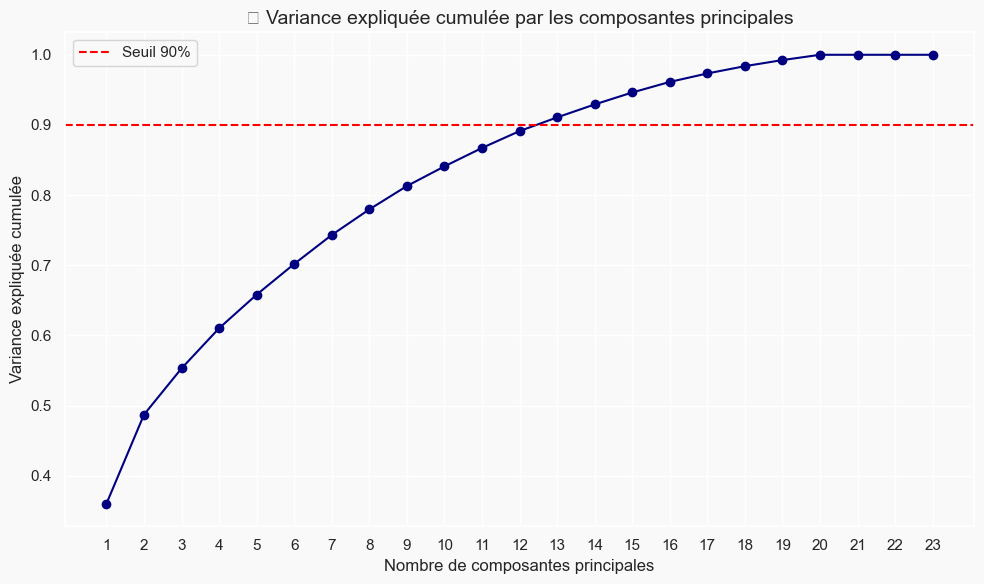

✅ La variance cumulée des 3 premières composantes est : 55.30%


In [ ]:

# Appliquer PCA sur toutes les composantes possibles
pca_full = PCA()
pca_full.fit(scaled_ds)

# Variance expliquée par chaque composante
explained_variance_full = pca_full.explained_variance_ratio_

# Variance cumulée
cumulative_variance_full = np.cumsum(explained_variance_full)

# Affichage de la variance expliquée cumulée
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_full) + 1), cumulative_variance_full, marker='o', linestyle='-', color='navy')
plt.title("🎯 Variance expliquée cumulée par les composantes principales", fontsize=14)
plt.xlabel("Nombre de composantes principales", fontsize=12)
plt.ylabel("Variance expliquée cumulée", fontsize=12)
plt.xticks(range(1, len(cumulative_variance_full) + 1))
plt.axhline(y=0.90, color='red', linestyle='--', label='Seuil 90%')  # Ligne de référence
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Affichage optionnel de la variance cumulée pour 3 composantes
print(f"✅ La variance cumulée des 3 premières composantes est : {cumulative_variance_full[2]:.2%}")


### Choix du nombre de composantes principales

Le graphique ci-dessus présente la variance expliquée cumulée par les composantes principales issues de l’Analyse en Composantes Principales (ACP). On observe que la variance expliquée augmente rapidement avec les premières composantes, puis la courbe s’aplatit progressivement.

Bien que le seuil des 90% de variance expliquée soit atteint autour de la 13ᵉ composante, nous faisons le choix de retenir uniquement les **4 premières composantes principales**. En effet, ces 4 axes permettent déjà d’expliquer (**plus de 61% des information**) une grande partie de la variance totale des données, tout en simplifiant fortement la structure du jeu de données. Ce choix se justifie par la volonté de :
- **Réduire la complexité** du modèle,
- **Faciliter la visualisation** et l’interprétation des résultats,
- **Limiter le risque de surapprentissage** lors des étapes ultérieures de clustering.


Ainsi, l’analyse des clusters et le profilage des clients seront réalisés sur la base de ces **4 axes principaux** issus de l’ACP.
> **Remarque :** Selon les bonnes pratiques en analyse de données, on considère généralement qu’un seuil de 60% à 70% de variance expliquée est suffisant pour garantir une représentation fidèle des données d’origine tout en simplifiant leur structure (Husson et al., 2011).


In [21]:
# Initialisation de l'ACP pour réduire les dimensions (features) à 4
pca = PCA(n_components=4)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=["axe1", "axe2", "axe3", "axe4"])
PCA_ds.describe().T


,count,mean,std,min,25%,50%,75%,max
axe1,2212.0,2.569775e-17,2.878602,-5.978124,-2.539470,-0.781595,2.386380,7.452915
axe2,2212.0,5.139550e-17,1.709469,-4.194757,-1.323929,-0.173721,1.234851,6.168189
axe3,2212.0,-1.606109e-17,1.231687,-3.625248,-0.853713,-0.050842,0.863974,6.750458
axe4,2212.0,1.284887e-17,1.147354,-3.127582,-0.758827,-0.012351,0.888047,3.403542


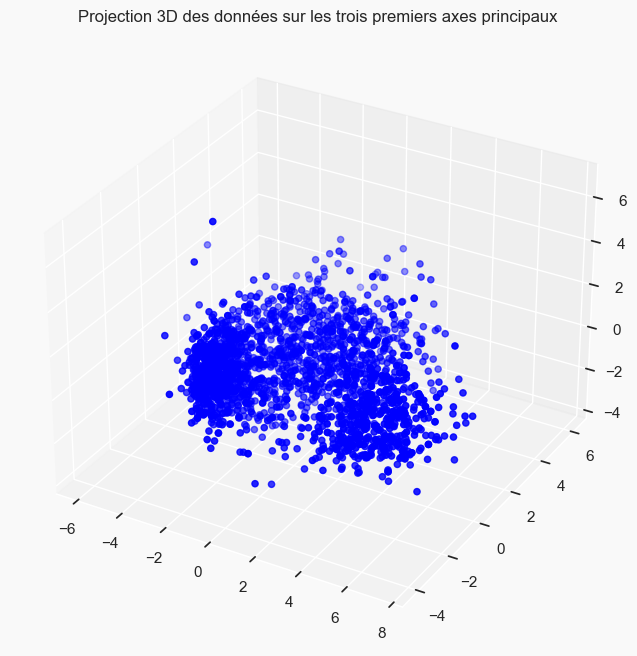

In [22]:
# Projection 3D des données dans l'espace réduit à 4 dimensions (visualisation sur les 3 premiers axes)
x = PCA_ds["axe1"]
y = PCA_ds["axe2"]
z = PCA_ds["axe3"]

# Tracé du nuage de points 3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, c="blue", marker="o")
ax.set_title("Projection 3D des données sur les trois premiers axes principaux")
plt.show()



***

<a id="6"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">📊 CLUSTERING</p>

Maintenant que j’ai réduit les attributs à **quatre dimensions principales** grâce à l’ACP, on va procéder à une segmentation des clients par la méthode de **clustering agglomératif**. Le clustering agglomératif est une approche hiérarchique qui consiste à fusionner progressivement les individus jusqu’à obtenir le nombre de groupes souhaité.

**Étapes du clustering**
* Détermination du nombre optimal de clusters grâce à la méthode du coude
* Segmentation via le clustering agglomératif (Agglomerative Clustering)
* Analyse et visualisation des groupes obtenus à l’aide de graphiques de dispersion


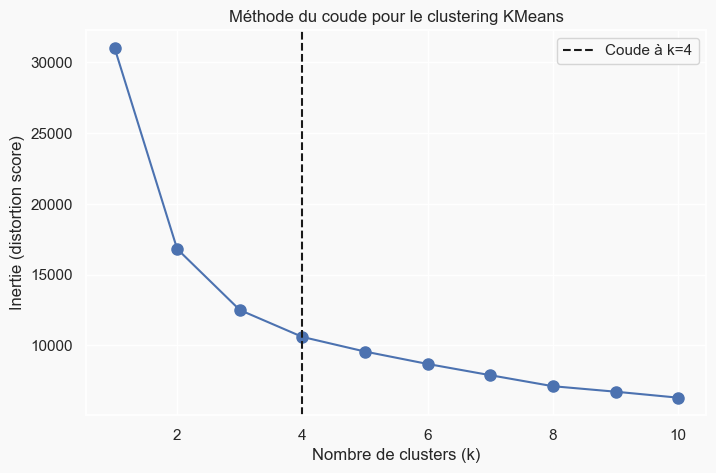

In [ ]:

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(PCA_ds)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.axvline(x=4, linestyle='--', color='k', label='Coude à k=4')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (distortion score)")
plt.title("Méthode du coude pour le clustering KMeans")
plt.legend()
plt.grid(True)
plt.show()



Le graphique ci-dessus représente l’évolution de l’inertie (somme des distances intra-cluster) en fonction du nombre de clusters formés. On observe que l’inertie diminue fortement lorsque le nombre de clusters passe de 2 à 4, puis la décroissance devient moins marquée au-delà de 4 clusters.

>Par consequent, le point d’inflexion de la courbe (le “coude”) situé à **k = 4** indique que **quatre clusters** constituent un choix optimal. Cela permet de maximiser la séparation entre les groupes tout en évitant de complexifier inutilement la segmentation. Ce nombre de clusters sera donc retenu pour la suite de l’analyse.


In [24]:
# Initialisation du modèle de Clustering Agglomératif (Agglomerative Clustering)
AC = AgglomerativeClustering(n_clusters=4)

# Ajustement du modèle et prédiction des clusters
yhat_AC = AC.fit_predict(PCA_ds)
PCA_ds["Clusters"] = yhat_AC

# Ajout de la variable "Clusters" au dataframe original
data["Clusters"] = yhat_AC


Pour examiner les groupes formés, observons la répartition des clusters dans l’espace 3D.


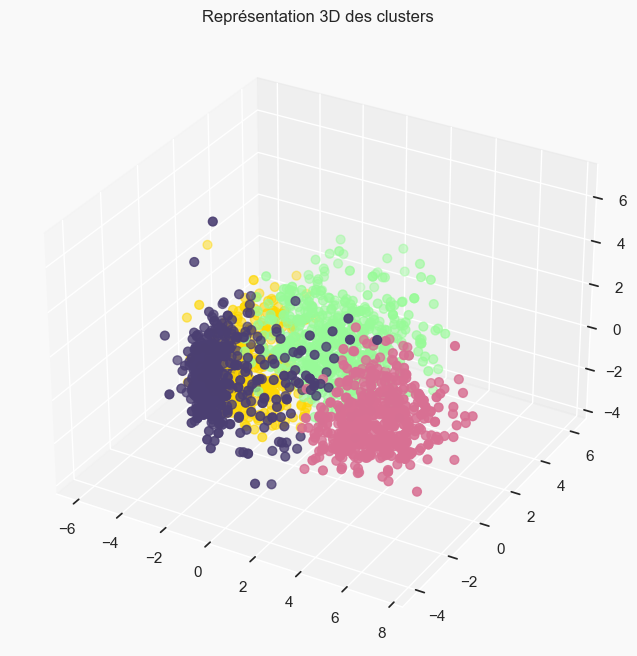

In [25]:
# Visualisation des clusters en 3D
fig = plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d')
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"], marker='o', cmap=cmap)
ax.set_title("Représentation 3D des clusters")
plt.show()


La visualisation 3D permet de constater que les individus sont correctement répartis en quatre groupes distincts, ce qui confirme la capacité du clustering agglomératif à segmenter efficacement les clients selon leurs caractéristiques principales.

Nous pouvons désormais passer à l’évaluation du modèle afin de mesurer la qualité de la segmentation obtenue.
***

<a id="7"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;"> 📈EVALUATING MODELS</p>


Nous ne disposons pas de variable cible pour évaluer  directement notre modèle. Nous allons maintenant analyser les profils des groupes obtenus afin de mieux comprendre la structure des clusters formés.

Pour cela, nous allons examiner les données selon l’appartenance aux différents clusters grâce à une analyse exploratoire, et en tirer des conclusions sur la nature de chaque groupe.

**Commençons par observer la répartition des individus au sein des différents clusters.**


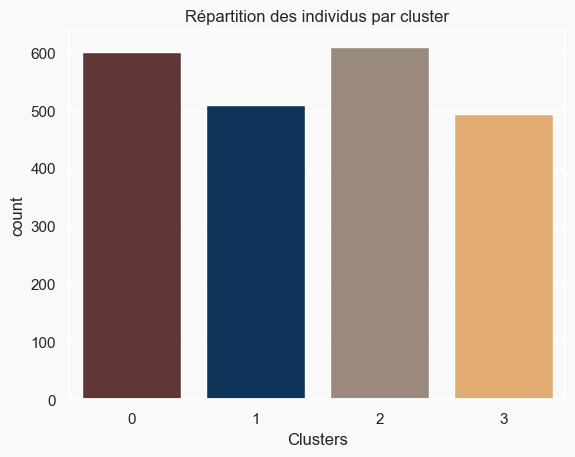

In [26]:
# Visualisation de la répartition des individus dans chaque cluster
pal = ["#682F2F", "#003366", "#9F8A78", "#F3AB60"]
pl = sns.countplot(x=data["Clusters"], palette=pal)
pl.set_title("Répartition des individus par cluster")
plt.show()


> Le graphique ci-dessus montre la répartition des individus dans chacun des quatre clusters formés. On observe que les groupes sont relativement équilibrés en effectif, aucun cluster n’étant largement sur- ou sous-représenté. Cela indique que la méthode de clustering a permis de constituer des groupes de taille comparable, ce qui est favorable pour l’analyse et le profilage ultérieur des segments de clients.


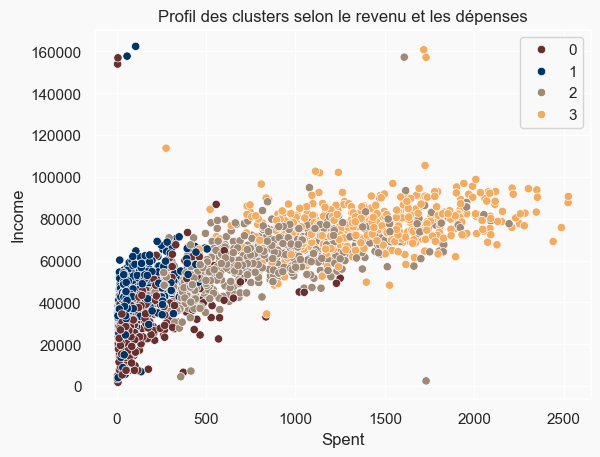

In [27]:
# Profil des clusters selon le revenu et les dépenses
pl = sns.scatterplot(data=data, x="Spent", y="Income", hue="Clusters", palette=pal)
pl.set_title("Profil des clusters selon le revenu et les dépenses")
plt.legend()
plt.show()


**L’analyse du nuage de points Revenu vs Dépenses met en lumière des profils distincts pour chaque cluster :**
* **Groupe 0 :** niveau de dépenses élevé et revenu moyen
* **Groupe 1 :** niveau de dépenses et de revenu tous deux élevés
* **Groupe 2 :** dépenses faibles et revenu faible
* **Groupe 3 :** dépenses élevées malgré un revenu faible

Cette segmentation révèle des comportements de consommation variés au sein de la clientèle, ce qui pourra orienter des stratégies marketing différenciées.

Nous allons examiner plus en détail la répartition des clusters en fonction des différents produits proposés : vins, fruits, viandes, poissons, confiseries et produits en or.


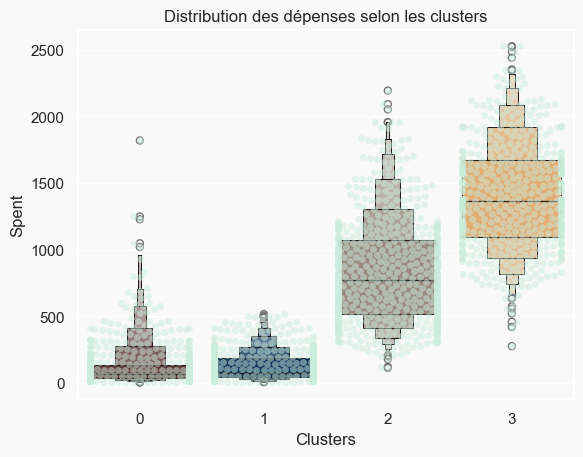

In [28]:
# Répartition des dépenses par cluster (swarmplot et boxenplot)
plt.figure()
pl = sns.swarmplot(x=data["Clusters"], y=data["Spent"], color="#CBEDDD", alpha=0.5)
pl = sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
pl.set_title("Distribution des dépenses selon les clusters")
plt.show()


Le graphique ci-dessus illustre la distribution des dépenses totales (« Spent ») au sein de chaque cluster. On observe que :

- Les groupes 2 et 3 présentent des niveaux de dépenses nettement plus élevés que les groupes 0 et 1.
- Le cluster 3 regroupe les individus aux dépenses les plus élevées, suivi de près par le cluster 2.
- À l’inverse, les clusters 0 et 1 sont composés de clients ayant des dépenses globalement faibles.

Cela confirme la diversité des comportements de consommation entre les différents segments identifiés.


Qu'en est t'il des performances des campagnes marketing passées?

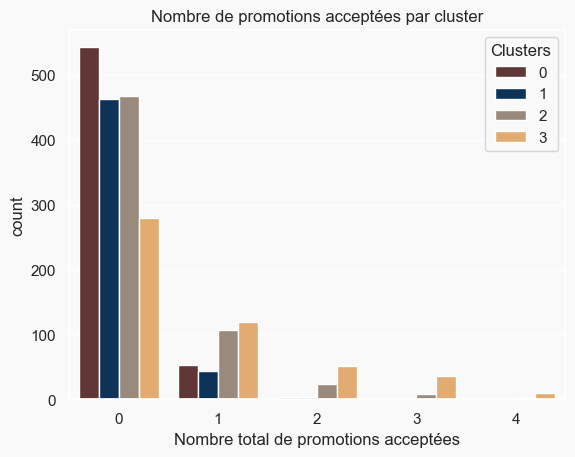

In [29]:
# Création d'une variable indiquant le nombre total de promotions acceptées
data["Total_Promos"] = (
    data["AcceptedCmp1"] + data["AcceptedCmp2"] + data["AcceptedCmp3"] + data["AcceptedCmp4"] + data["AcceptedCmp5"]
)

# Affichage du nombre total de promotions acceptées, par cluster
plt.figure()
pl = sns.countplot(x=data["Total_Promos"], hue=data["Clusters"], palette=pal)
pl.set_title("Nombre de promotions acceptées par cluster")
pl.set_xlabel("Nombre total de promotions acceptées")
plt.show()


>Aucun client n’a d’ailleurs accepté l’ensemble des cinq offres proposées. Ces résultats suggèrent qu’il serait pertinent de concevoir des campagnes plus ciblées et mieux planifiées afin de stimuler davantage les ventes.


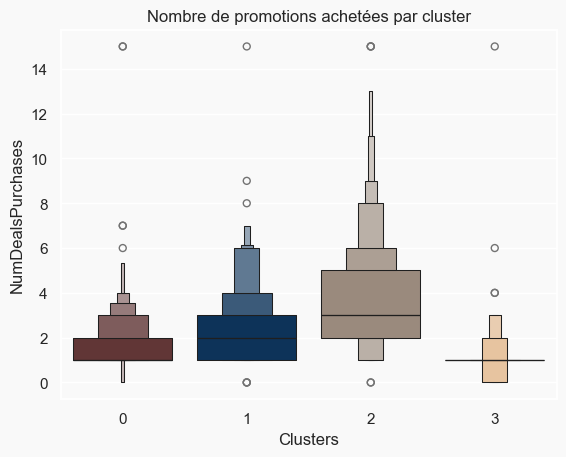

In [30]:
# Visualisation du nombre de promotions achetées par cluster
plt.figure()
pl = sns.boxenplot(y=data["NumDealsPurchases"], x=data["Clusters"], palette=pal)
pl.set_title("Nombre de promotions achetées par cluster")
plt.show()


>Le graphique ci-dessus montre que les clients du **cluster 2** sont ceux qui achètent en moyenne le plus grand nombre de promotions (« deals »), avec une répartition qui s’étend jusqu’à des valeurs très élevées. Les clusters 1 et 0 réalisent également des achats promotionnels, mais dans des proportions moindres. En revanche, le **cluster 3** regroupe majoritairement des clients qui achètent très peu de promotions, avec une dispersion beaucoup plus faible.

Contrairement à la première impression, ce sont donc les clients du cluster 2 qui réagissent le mieux aux offres spéciales, tandis que les autres segments sont moins engagés sur ce type de promotions.


<Figure size 640x480 with 0 Axes>

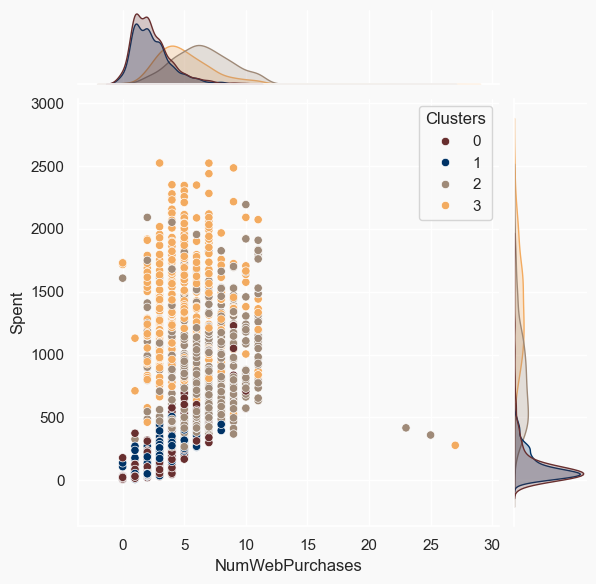

<Figure size 640x480 with 0 Axes>

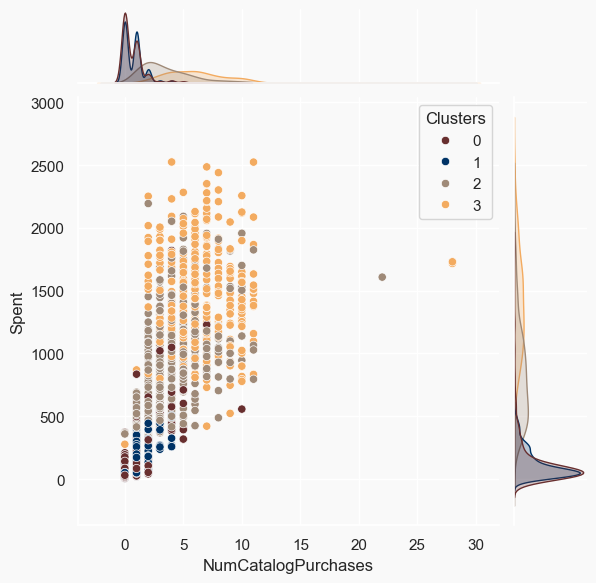

<Figure size 640x480 with 0 Axes>

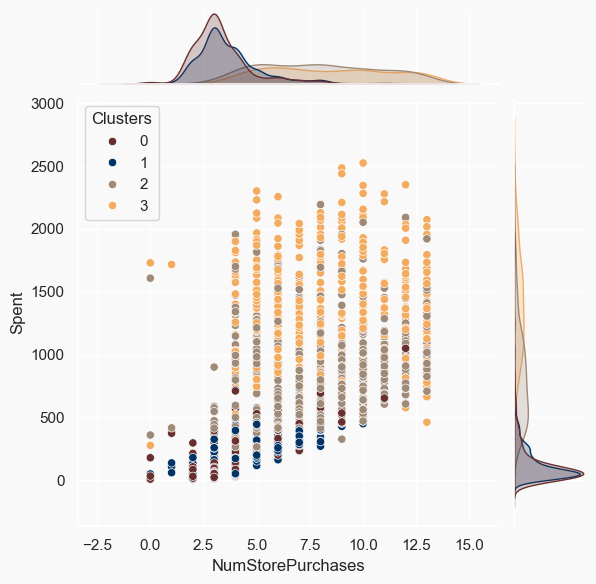

<Figure size 640x480 with 0 Axes>

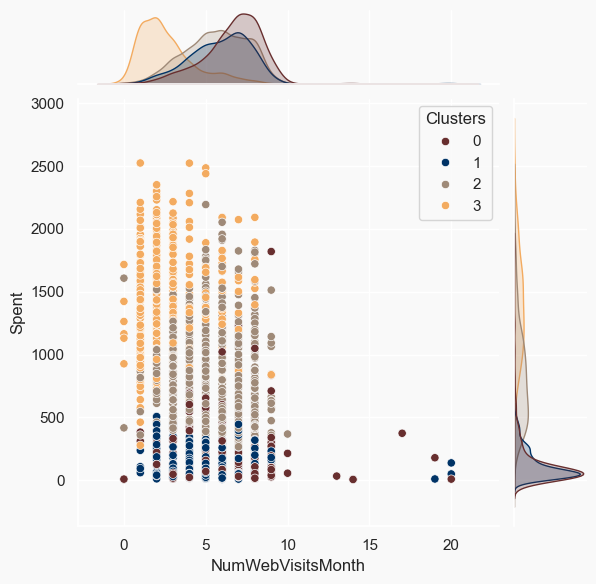

In [31]:
# Pour une analyse plus détaillée des styles d'achat
lieux_achat = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"]

for var in lieux_achat:
    plt.figure()
    sns.jointplot(x=data[var], y=data["Spent"], hue=data["Clusters"], palette=pal)
    plt.show()


L’analyse croisée des différents canaux d’achat (web, catalogue, magasin physique et visites sur le site) avec le montant dépensé met en évidence des comportements d’achat variés au sein des clusters. On constate notamment que certains groupes concentrent l’essentiel des dépenses sur des canaux spécifiques, tandis que d’autres adoptent des pratiques plus dispersées.

>Ces résultats soulignent la nécessité d’approfondir le **profiling** afin de mieux caractériser les spécificités de chaque segment de clients et d’identifier les leviers d’action commerciale les plus pertinents.


<a id="8"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;"> 👥PROFILING</p>

Après avoir constitué les clusters et analysé leurs habitudes d’achat, il est temps de s’intéresser à la composition de ces groupes. Pour cela, nous allons réaliser un **profilage** des clusters afin de déterminer quels sont les clients les plus précieux (« star customers ») et quels segments nécessitent une attention particulière de la part de l’équipe marketing du magasin.

>>Pour ce faire, nous allons examiner plusieurs caractéristiques personnelles des clients en fonction de leur appartenance à chaque cluster. Cette analyse permettra de mieux comprendre la nature de chaque segment et d’orienter les conclusions stratégiques.


**Pour affiner le profil des différents clusters, examinons la relation entre certaines caractéristiques personnelles des clients et leurs dépenses totales, selon leur groupe d’appartenance.**


<Figure size 640x480 with 0 Axes>

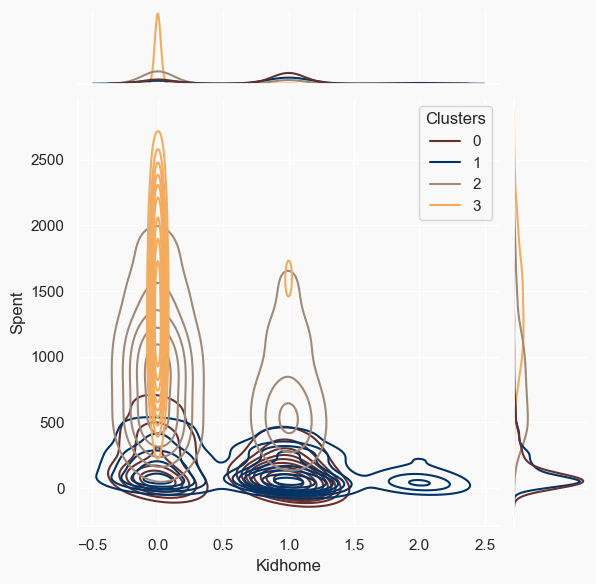

<Figure size 640x480 with 0 Axes>

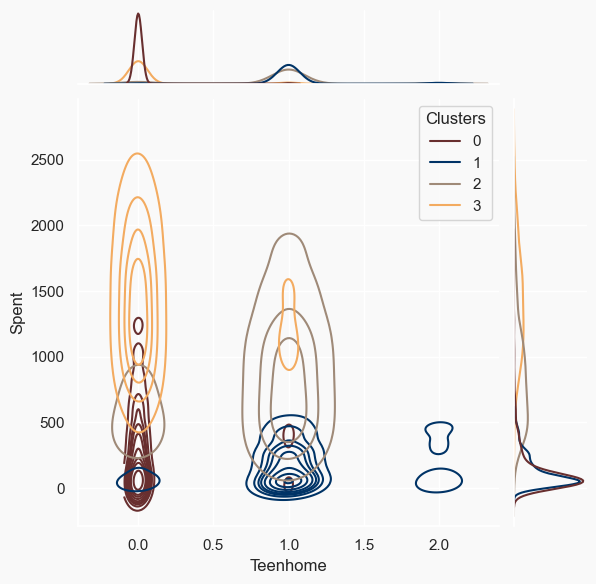

<Figure size 640x480 with 0 Axes>

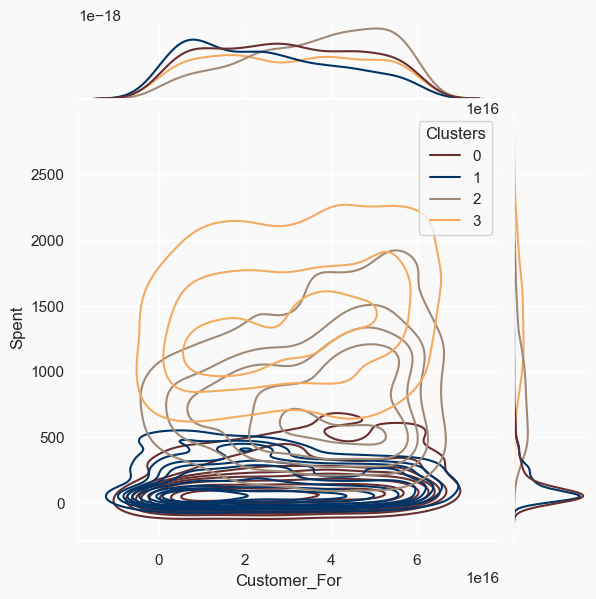

<Figure size 640x480 with 0 Axes>

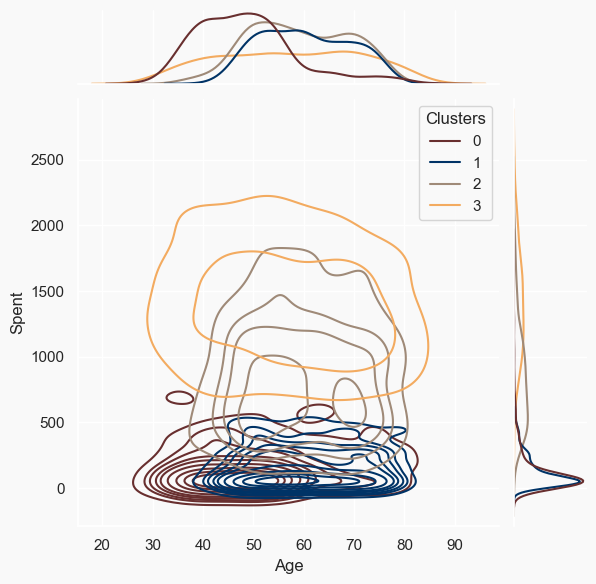

<Figure size 640x480 with 0 Axes>

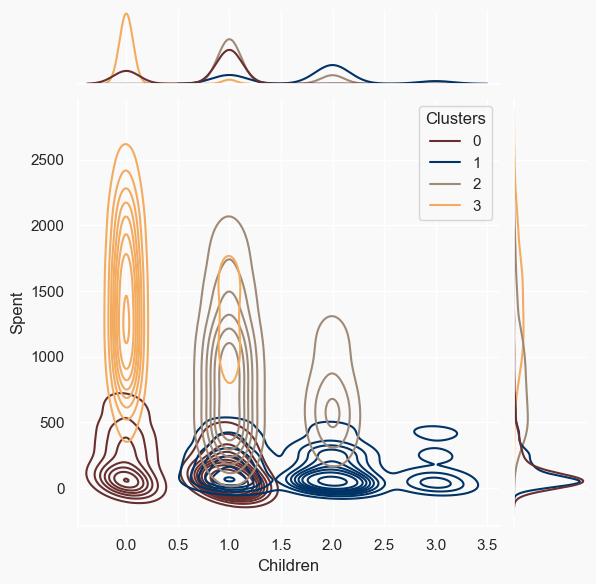

<Figure size 640x480 with 0 Axes>

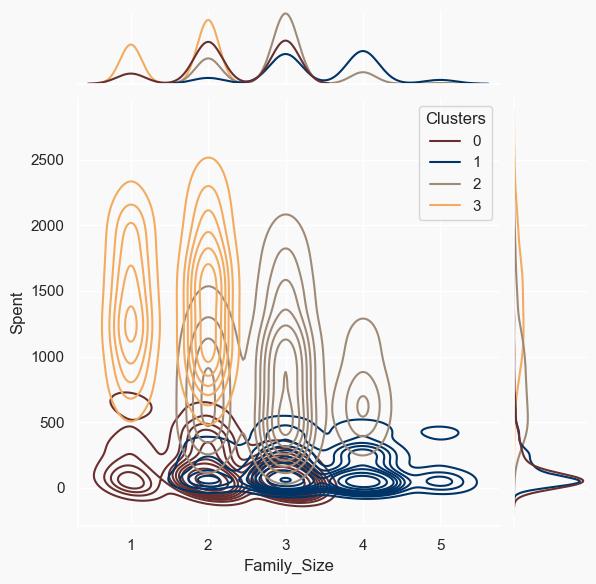

<Figure size 640x480 with 0 Axes>

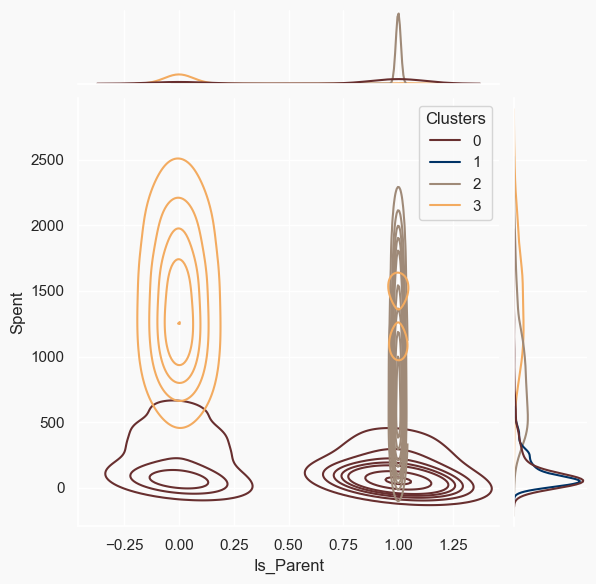

<Figure size 640x480 with 0 Axes>

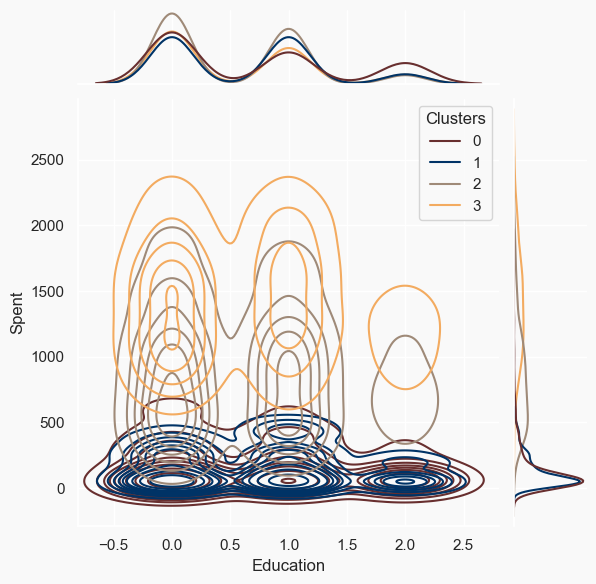

<Figure size 640x480 with 0 Axes>

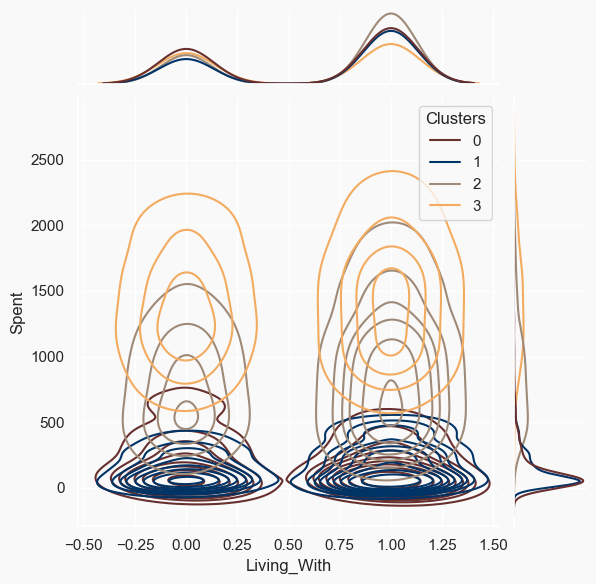

In [32]:
# Analyse du profil personnel des clients selon leur cluster
variables_personnelles = ["Kidhome", "Teenhome", "Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education", "Living_With"]

for var in variables_personnelles:
    plt.figure()
    sns.jointplot(x=data[var], y=data["Spent"], hue=data["Clusters"], kind="kde", palette=pal)
    plt.show()


**PROFILAGE DES CLIENTS**

|       Cluster | Description synthétique                                                                                                                                                                                                                                                                                                         |
| ------------: | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Cluster 0** | • Ce sont **systématiquement des parents**, généralement dans des foyers de **2 à 4 personnes**.<br>• Un sous-groupe est constitué de **parents isolés**.<br>• La majorité a **au moins un adolescent à charge**.<br>• Ils sont **relativement plus âgés**.                                                                     |
| **Cluster 1** | • Ils **ne sont pas parents** dans leur grande majorité.<br>• Composés surtout de **couples** (légèrement plus nombreux que les célibataires).<br>• Le ménage ne dépasse **jamais 2 membres**.<br>• Ce cluster couvre **toutes les tranches d’âge**.<br>• Il s’agit d’un **groupe à revenu élevé**, avec des dépenses marquées. |
| **Cluster 2** | • La **majorité sont des parents jeunes**.<br>• Les familles comptent **2 à 3 membres**, souvent avec **un seul enfant (non adolescent)**.<br>• Groupe **plus jeune que la moyenne**.<br>• Leur comportement d’achat reste modéré.                                                                                              |
| **Cluster 3** | • Composés **uniquement de parents**, dans des familles de **2 à 5 personnes**.<br>• La plupart ont **un adolescent à domicile**.<br>• Ils sont **plus âgés**, mais appartiennent à un **groupe à faibles revenus**.<br>• Malgré des revenus modestes, leur engagement dans certaines offres est élevé.                         |


<a id="9"></a>
# <p style="background-color:#003366;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;"> 🧾 CONCLUSION</p>


Ce projet avait pour objectif d’identifier des groupes homogènes de clients à partir de leurs caractéristiques sociodémographiques et comportementales, en vue d’orienter des actions marketing ciblées.

Pour ce faire, une approche de **clustering non supervisé** a été mise en œuvre, précédée d’une **réduction de dimensionnalité** par Analyse en Composantes Principales (ACP). L’algorithme de **clustering agglomératif** a permis d’extraire **quatre clusters** distincts de clients, à partir desquels un **profilage approfondi** a été réalisé.

Les analyses ont mis en évidence des différences significatives entre les groupes, tant au niveau de la structure familiale que des niveaux de revenu, de dépenses et de réceptivité aux campagnes promotionnelles. Ces résultats offrent des perspectives intéressantes pour la conception de **stratégies marketing personnalisées**, plus efficaces et mieux ciblées.

En somme, cette étude illustre la pertinence des techniques de data mining dans la segmentation client, en fournissant aux décideurs des informations exploitables pour l’optimisation des campagnes commerciales et l’amélioration de la relation client.